# Flow + Membrane Hybrid Segmentation — walkthrough

Interactive companion to `flow_membrane_seg.py`. Same frozen pipeline, step by step, with plots.

**Idea:** each signal does only what it is reliable at —
- **flow divergence** -> cell *centers* (markers), robust even with dim membrane
- **membrane wall** -> boundary *where a wall exists*
- **flow separatrix** -> boundary *where membrane is absent* (no arbitrary/adjacency guesses)
- **membrane veto** -> drop splits with no wall behind them

Input is a Cellpose `*_seg.npy` (has `img`, `flows`, and usually `masks`).
Keep this notebook next to `flow_membrane_seg.py`.

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.segmentation import find_boundaries
from skimage.morphology import dilation, disk

from pathlib import Path
import pandas as pd
from skimage import morphology, segmentation

import flow_membrane_seg as fm   # the packaged module (same folder)

SEG_DIR  = "/omics/odcf/analysis/OE0622_projects/mibi_shared/Amir/preprocessing/segmentation/positivity_map_v3/sorted_by_quality/High/whole_cell/TN2_hiRes_Amir_posMap2"   # folder of Cellpose *_seg.npy
SEG_PATH = sorted(Path(SEG_DIR).glob("*_seg.npy"))[0]                     # <-- one FOV to preview
CROP = (560, 560, 1000)                      # (y, x, size); None = full tile

## 1. Load and run the full pipeline

In [39]:
seg = fm.load_seg(SEG_PATH)
params = fm.Params()          # defaults; edit the three knobs in section 5
labels, ctx = fm.run_pipeline(seg, params)

base = int(np.asarray(seg["masks"]).max()) if seg.get("masks") is not None else None
print(f"flow sinks : {ctx['n_markers']}")
print(f"Cellpose   : {base}")
print(f"pipeline   : {ctx['n_cells']}")
print(f"nucleus is plane {ctx['nuc_plane']}  (auto-detected)")

flow sinks : 323
Cellpose   : 210
pipeline   : 118
nucleus is plane 1  (auto-detected)


## 2. The channels (auto-detected)
Nucleus = the channel bright at the flow sinks; the other is membrane.

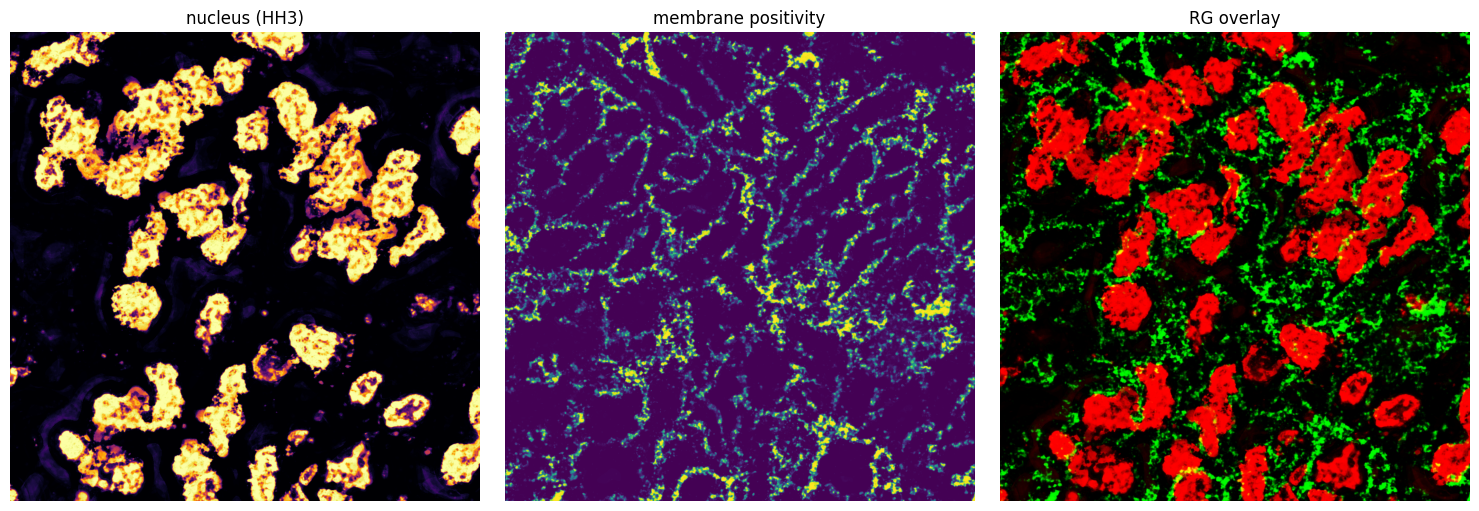

In [40]:
def crop(a, C=CROP):
    if C is None: return a
    y,x,s = C; return a[y:y+s, x:x+s]

fig, ax = plt.subplots(1, 3, figsize=(15,5))
ax[0].imshow(crop(ctx['nucleus']), cmap='inferno'); ax[0].set_title('nucleus (HH3)')
ax[1].imshow(crop(ctx['membrane']), cmap='viridis'); ax[1].set_title('membrane positivity')
rg = np.zeros(crop(ctx['nucleus']).shape+(3,))
rg[...,0]=np.clip(crop(ctx['nucleus']),0,1); rg[...,1]=np.clip(crop(ctx['membrane']),0,1)
ax[2].imshow(rg); ax[2].set_title('RG overlay')
for a in ax: a.axis('off')
plt.tight_layout(); plt.show()

## 3. Flow divergence -> sinks
Divergence is strongly **negative at cell centers** (sinks = markers) and **positive along seams** (watershed ridges). Watershed *this*, not the flow magnitude.

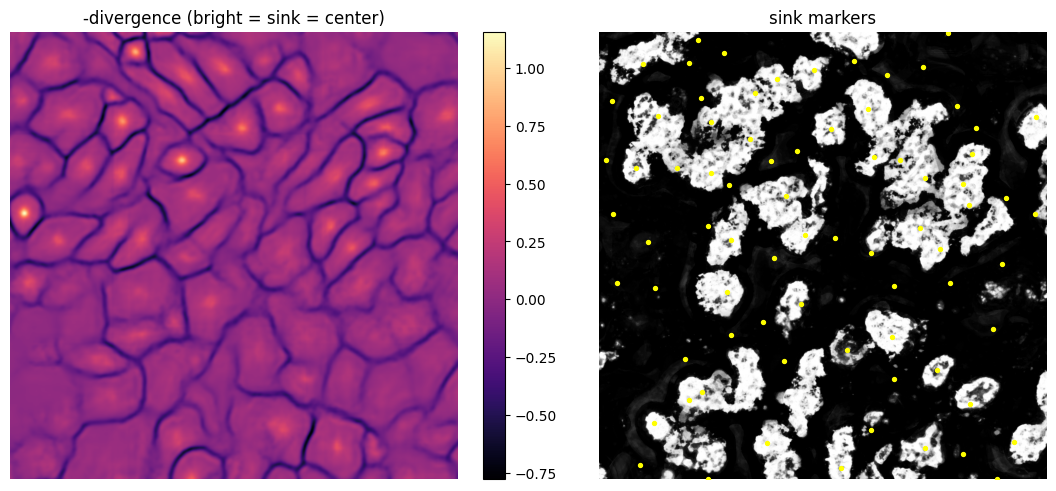

In [41]:
div = ctx['div']
fig, ax = plt.subplots(1, 2, figsize=(11,5))
im0 = ax[0].imshow(crop(-div), cmap='magma'); ax[0].set_title('-divergence (bright = sink = center)')
plt.colorbar(im0, ax=ax[0], fraction=0.046)
ax[1].imshow(crop(ctx['nucleus']), cmap='gray')
ys,xs = np.where(crop(ctx['markers'])>0); ax[1].scatter(xs, ys, s=8, c='yellow')
ax[1].set_title('sink markers')
for a in ax: a.axis('off')
plt.tight_layout(); plt.show()

## 4. Elevation and result
Elevation = membrane wall (+skeleton) + `flow_weight` x divergence. Membrane wins where it exists; the flow separatrix places the seam where membrane is absent.

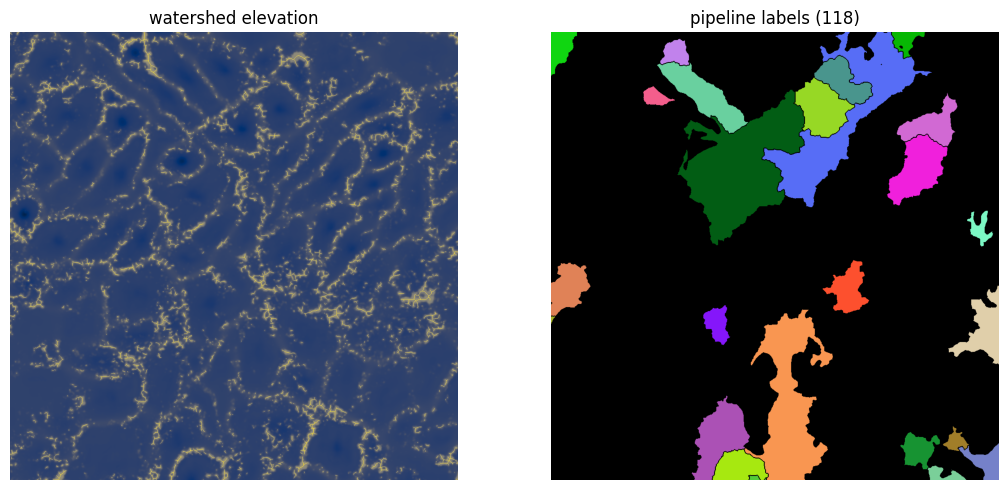

In [42]:
elev = fm.build_elevation(ctx['membrane'], div, params)
fig, ax = plt.subplots(1, 2, figsize=(11,5))
ax[0].imshow(crop(elev), cmap='cividis'); ax[0].set_title('watershed elevation'); ax[0].axis('off')
rng = np.random.default_rng(0)
lut = rng.random((int(labels.max())+1,3)); lut[0]=0
lab_rgb = lut[crop(labels)]
lab_rgb[find_boundaries(crop(labels),mode='inner')] = 0
ax[1].imshow(lab_rgb); ax[1].set_title(f'pipeline labels ({int(labels.max())})'); ax[1].axis('off')
plt.tight_layout(); plt.show()

## 5. Compare to Cellpose + tune the three knobs
Yellow (solid) = Cellpose, cyan (dashed) = pipeline. Edit `sink_h` / `flow_weight` / `veto_wall` and re-run.

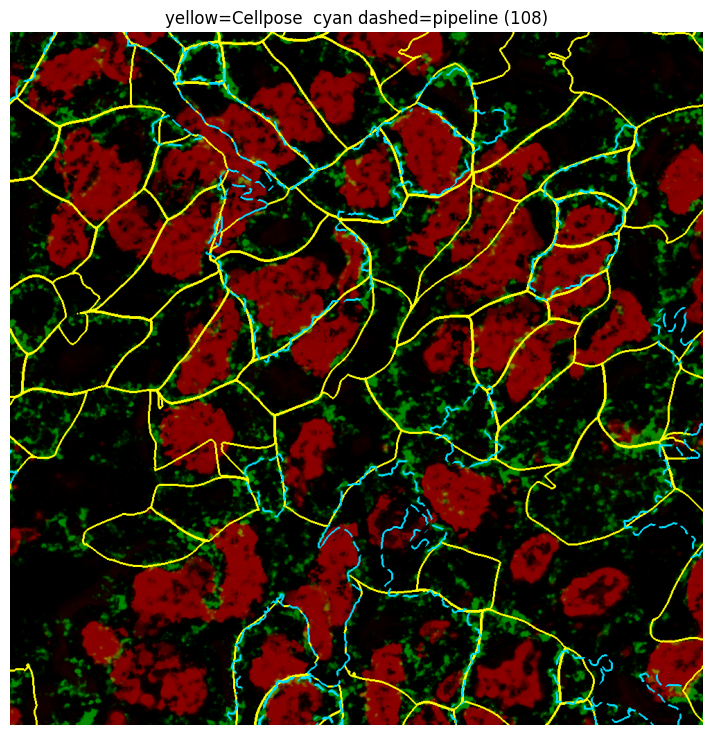

In [43]:
params = fm.Params(sink_h=0.12, flow_weight=2, veto_wall=0.45)   # <-- the three knobs
labels, ctx = fm.run_pipeline(seg, params)

y,x,s = CROP if CROP else (0,0,min(ctx['nucleus'].shape))
sub = np.s_[y:y+s, x:x+s]
rgb = np.zeros((s,s,3),np.float32)
rgb[...,0]=np.clip(ctx['nucleus'][sub],0,1); rgb[...,1]=np.clip(ctx['membrane'][sub],0,1); rgb*=0.55
out=(np.clip(rgb,0,1)*255).astype(np.uint8)
fb=dilation(find_boundaries(labels[sub],mode='inner'),disk(1))
Y,X=np.mgrid[0:s,0:s]; fb=fb&(((X+Y)%30)<22)
if seg.get('masks') is not None:
    cb=dilation(find_boundaries(np.asarray(seg['masks'])[sub],mode='inner'),disk(1)); out[cb]=[255,255,0]
out[fb]=[0,220,255]
plt.figure(figsize=(9,9)); plt.imshow(out)
plt.title(f"yellow=Cellpose  cyan dashed=pipeline ({int(labels.max())})"); plt.axis('off'); plt.show()

## 6. Preview hole removal — VISUALIZATION ONLY

The real hole removal happens inside `flow_membrane_seg.py` (`remove_holey`, controlled
by `hole_ratio` in `Params`, currently 0.99). This cell does **not** process anything that
gets saved — it only lets you *see* which masks a given `hole_ratio` would delete, so you
can pick the value to set in the `.py` file.

Keep `PREVIEW_RATIO` here equal to `hole_ratio` in the script so the preview matches the batch.
`ratio = real area / hole-filled area`;  1.0 = solid, below cutoff = has a hole.

total cells      : 108
would be removed : 0   (at PREVIEW_RATIO=0.99)
after removal    : 108
NOTE: 'labels' is unchanged; the script does the real removal during the batch.


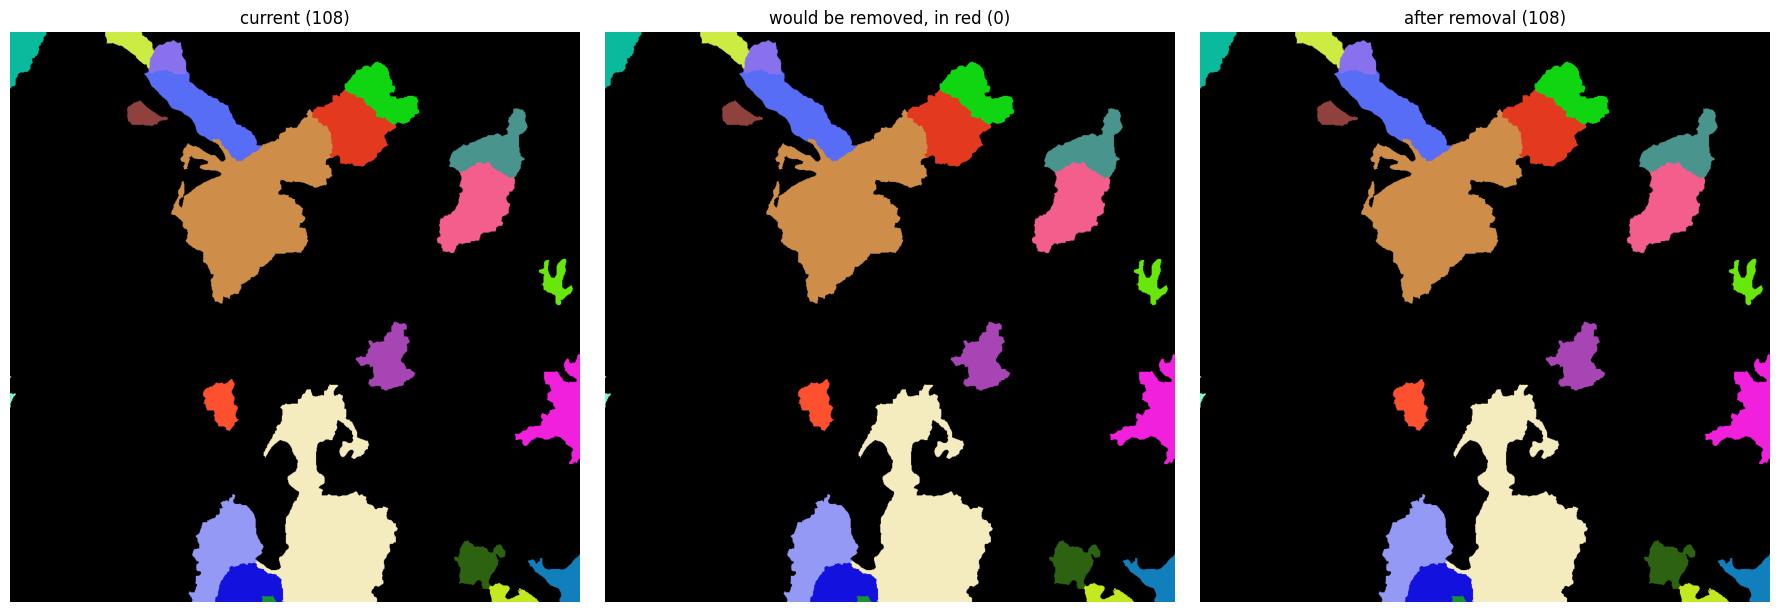

In [44]:
# VISUALIZATION ONLY — nothing here is saved. The script already removes holes.
# Use this to choose hole_ratio, then set that same value in Params in flow_membrane_seg.py.
from scipy.ndimage import binary_fill_holes
from skimage.measure import regionprops
from skimage.segmentation import relabel_sequential

PREVIEW_RATIO = 0.99   # keep equal to hole_ratio in the .py file

holey = np.zeros_like(labels, dtype=bool)
survivors = labels.copy()
n_holey = 0
for r in regionprops(labels):
    filled = binary_fill_holes(r.image)          # r.image = mask cropped to its bounding box
    ratio = r.image.sum() / filled.sum()
    if ratio < PREVIEW_RATIO:
        holey[labels == r.label] = True
        survivors[labels == r.label] = 0
        n_holey += 1
survivors, _, _ = relabel_sequential(survivors)

print(f"total cells      : {int(labels.max())}")
print(f"would be removed : {n_holey}   (at PREVIEW_RATIO={PREVIEW_RATIO})")
print(f"after removal    : {int(survivors.max())}")
print("NOTE: 'labels' is unchanged; the script does the real removal during the batch.")

# --- comparison: current | holey flagged red | after removal ---
def _crop(a):
    if CROP is None: return a
    y, x, s = CROP; return a[y:y+s, x:x+s]

rng = np.random.default_rng(0)
lut = rng.random((int(labels.max())+1, 3)); lut[0] = 0

fig, ax = plt.subplots(1, 3, figsize=(18, 6))
ax[0].imshow(lut[_crop(labels)]); ax[0].set_title(f'current ({int(labels.max())})'); ax[0].axis('off')
ax[1].imshow(lut[_crop(labels)])
ax[1].contourf(_crop(holey), levels=[0.5, 1], colors='red', alpha=1.0)
ax[1].set_title(f'would be removed, in red ({n_holey})'); ax[1].axis('off')
ax[2].imshow(lut[_crop(survivors)]); ax[2].set_title(f'after removal ({int(survivors.max())})'); ax[2].axis('off')
plt.tight_layout(); plt.show()

## 7. Per-cell confidence table
Down-weight or exclude low-confidence cells downstream (weak wall + little nucleus) instead of trusting the mask uniformly.

In [45]:
rows = fm.cell_table(labels, ctx, params)
import pandas as pd
df = pd.DataFrame(rows)
print("cells:", len(df), " low-confidence:", int(df.low_confidence.sum()))
display(df.head(10))
confident = df[(df.boundary_membrane >= params.veto_wall) | (df.nuclear_frac >= 0.05)]
print("kept for downstream:", len(confident))

cells: 108  low-confidence: 8


,label,area_px,boundary_membrane,nuclear_frac,mean_cellprob,sink_strength,low_confidence
0,1,1519,0.6184,0.1995,1.4432,0.1590,0
1,2,4965,0.8576,0.0481,1.4537,0.1684,0
2,3,6530,0.7837,0.5493,2.1840,0.7008,0
3,4,7690,0.6006,0.4421,0.9972,0.3593,0
4,5,16908,0.6145,0.3434,0.7877,0.1691,0
5,6,27864,0.5232,0.1199,1.5389,0.2620,0
6,7,6650,0.7812,0.6498,1.6958,0.3518,0
7,8,7824,0.6820,0.2566,1.8873,0.3418,0
8,9,17819,0.5308,0.0746,0.8398,0.2055,0
9,10,32169,0.6458,0.1696,1.3381,0.3274,0


kept for downstream: 100


---

# Parameter optimisation

Everything below tunes the parameters on a **handful of FOVs** before committing
to a full run. Sections 1-7 above preview a single FOV; this measures several.

In [46]:
# FOVs to optimise on. Few enough to be quick, spread across the folder so they
# are not all the same tissue.
N_SAMPLE = 4

ALL_SEG = sorted(Path(SEG_DIR).glob("*_seg.npy"))
idx = np.linspace(0, len(ALL_SEG) - 1, min(N_SAMPLE, len(ALL_SEG))).round().astype(int)
SAMPLE = [ALL_SEG[i] for i in idx]
print(f"{len(ALL_SEG)} FOVs available; optimising on {len(SAMPLE)}:")
for f in SAMPLE:
    print("  ", f.name)

149 FOVs available; optimising on 4:
   A_1a_C01_R01_p2_seg.npy
   A_8f_C01_R01_seg.npy
   B_7c_C01_R01_seg.npy
   E_6c_C01_R01_seg.npy


## A. Where are cells lost?

Counts after each stage of `run_pipeline`. Tune the stage that is actually
costing you cells rather than guessing.

In [47]:
def presegment(seg, p):
    """Everything up to remove_small_objects. Depends on sink_h / flow_weight only."""
    img = np.asarray(seg["img"]).astype(np.float32)
    dY, dX, cellprob = fm.raw_flows(seg)
    fg = cellprob > p.cellprob_thr
    div = fm.divergence(dY, dX, p.div_sigma)
    _, membrane, _ = fm.detect_channels(img, div, fg, p.sink_h)
    markers = fm.get_markers(div, fg, p.sink_h)
    ws = segmentation.watershed(fm.build_elevation(membrane, div, p), markers, mask=fg)
    ws = morphology.remove_small_objects(ws, p.min_size)
    return ws, membrane, int(markers.max())


def stage_audit(seg_files, p=None):
    p = p or fm.Params()
    rows = []
    for f in seg_files:
        seg = fm.load_seg(str(f))
        ws, membrane, n_seeds = presegment(seg, p)
        v = fm.veto_merge(ws, membrane, p)
        h = fm.remove_holey(v, p)
        rows.append({
            "fov": f.stem,
            "cellpose": int(np.asarray(seg["masks"]).max()) if seg.get("masks") is not None else 0,
            "seeds": n_seeds,
            "after_watershed": len(np.unique(ws)) - 1,
            "after_veto": int(v.max()),
            "after_holey": int(h.max()),
        })
    df = pd.DataFrame(rows)
    tot = df.drop(columns="fov").sum()
    print(f"defaults: veto_wall={p.veto_wall} veto_min_border={p.veto_min_border} "
          f"hole_ratio={p.hole_ratio} sink_h={p.sink_h} flow_weight={p.flow_weight}\n")
    print(f"lost at veto step : {tot.after_watershed - tot.after_veto} "
          f"({(tot.after_watershed - tot.after_veto) / max(tot.after_watershed, 1):.0%})")
    print(f"lost at holey step: {tot.after_veto - tot.after_holey} "
          f"({(tot.after_veto - tot.after_holey) / max(tot.after_veto, 1):.0%})")
    return df


audit = stage_audit(SAMPLE)
audit

defaults: veto_wall=0.45 veto_min_border=5 hole_ratio=0.99 sink_h=0.12 flow_weight=1

lost at veto step : 220 (45%)
lost at holey step: 29 (11%)


,fov,cellpose,seeds,after_watershed,after_veto,after_holey
0,A_1a_C01_R01_p2_seg,210,323,316,141,118
1,A_8f_C01_R01_seg,17,34,30,30,30
2,B_7c_C01_R01_seg,28,77,72,30,29
3,E_6c_C01_R01_seg,14,68,67,64,59


## B. Parameter sweep

Two tiers, because the pipeline splits naturally:

- **`sink_h`, `flow_weight`** change the watershed, so each combination is
  recomputed from the flow field — expensive.
- **`veto_wall`, `veto_min_border`, `hole_ratio`** only post-process the
  watershed, so they are swept against a cached result — nearly free.

Keep the first two lists short; the last three can be long.

In [48]:
SINK_H      = [0.12]              # expensive - keep short
FLOW_WEIGHT = [1]                 # expensive - keep short
VETO_WALL   = [0.20, 0.25, 0.30, 0.45]
VETO_MIN_BORDER = [5, 20]
HOLE_RATIO  = [0.95, 0.99]


def sweep(seg_files, sink_hs=None, flow_weights=None, veto_walls=None,
          min_borders=None, hole_ratios=None):
    sink_hs      = SINK_H          if sink_hs      is None else sink_hs
    flow_weights = FLOW_WEIGHT     if flow_weights is None else flow_weights
    veto_walls   = VETO_WALL       if veto_walls   is None else veto_walls
    min_borders  = VETO_MIN_BORDER if min_borders  is None else min_borders
    hole_ratios  = HOLE_RATIO      if hole_ratios  is None else hole_ratios

    n_combo = (len(sink_hs) * len(flow_weights) * len(veto_walls)
               * len(min_borders) * len(hole_ratios))
    print(f"{n_combo} combinations x {len(seg_files)} FOVs "
          f"({len(sink_hs) * len(flow_weights)} watershed recomputes per FOV)")

    rows = []
    for f in seg_files:
        seg = fm.load_seg(str(f))
        n_cp = int(np.asarray(seg["masks"]).max()) if seg.get("masks") is not None else 0
        for sh in sink_hs:
            for fw in flow_weights:
                ws, membrane, _ = presegment(seg, fm.Params(sink_h=sh, flow_weight=fw))
                for vw in veto_walls:
                    for mb in min_borders:
                        merged = fm.veto_merge(
                            ws, membrane, fm.Params(veto_wall=vw, veto_min_border=mb))
                        for hr in hole_ratios:
                            lab = fm.remove_holey(merged, fm.Params(hole_ratio=hr))
                            _, cnt = np.unique(lab[lab > 0], return_counts=True)
                            rows.append({
                                "fov": f.stem, "sink_h": sh, "flow_weight": fw,
                                "veto_wall": vw, "veto_min_border": mb, "hole_ratio": hr,
                                "cellpose": n_cp, "n_cells": int(lab.max()),
                                "median_area": int(np.median(cnt)) if len(cnt) else 0,
                            })
    return pd.DataFrame(rows)


sw = sweep(SAMPLE)

KNOBS = ["sink_h", "flow_weight", "veto_wall", "veto_min_border", "hole_ratio"]
agg = (sw.groupby(KNOBS)
         .agg(cells=("n_cells", "sum"), cellpose=("cellpose", "sum"),
              median_area=("median_area", "median"))
         .reset_index())
agg["vs_cellpose"] = (agg["cells"] / agg["cellpose"]).round(2)
agg.sort_values("cells", ascending=False)

16 combinations x 4 FOVs (1 watershed recomputes per FOV)


,sink_h,flow_weight,veto_wall,veto_min_border,hole_ratio,cells,cellpose,median_area,vs_cellpose
2,0.12,1,0.20,20,0.95,434,269,5648.5,1.61
0,0.12,1,0.20,5,0.95,430,269,5605.5,1.60
6,0.12,1,0.25,20,0.95,416,269,5492.5,1.55
3,0.12,1,0.20,20,0.99,415,269,5605.5,1.54
4,0.12,1,0.25,5,0.95,412,269,5401.0,1.53
1,0.12,1,0.20,5,0.99,411,269,5565.5,1.53
7,0.12,1,0.25,20,0.99,396,269,5309.5,1.47
5,0.12,1,0.25,5,0.99,392,269,5225.0,1.46
10,0.12,1,0.30,20,0.95,388,269,5140.5,1.44
8,0.12,1,0.30,5,0.95,382,269,5019.5,1.42


## C. Look at the candidates

The table says what each setting *does*, not which is *right* — a higher count
can be correct splitting or it can be fragmentation. Draw the ones you are
choosing between.

In [ ]:
def preview(seg_path, p, crop=None, width=2, figsize=(8, 8)):
    """Cellpose (yellow) vs pipeline (cyan dashed) for one FOV under params `p`."""
    seg = fm.load_seg(str(seg_path))
    labels, ctx = fm.run_pipeline(seg, p)
    H, W = ctx["membrane"].shape
    y0, x0, s = crop if crop else (0, 0, min(H, W))
    s = max(1, min(s, H - y0, W - x0))
    sl = np.s_[y0:y0 + s, x0:x0 + s]

    rgb = np.zeros((s, s, 3), np.float32)
    rgb[..., 0] = np.clip(ctx["nucleus"][sl], 0, 1) * .75
    rgb[..., 1] = np.clip(ctx["membrane"][sl], 0, 1) * .75

    if seg.get("masks") is not None:
        cb = dilation(find_boundaries(np.asarray(seg["masks"])[sl], mode="inner"), disk(width))
        rgb[cb] = [1, 1, 0]
    fb = dilation(find_boundaries(labels[sl], mode="inner"), disk(width))
    Y, X = np.mgrid[0:s, 0:s]
    rgb[fb & (((X + Y) % 30) < 22)] = [0, .86, 1]

    plt.figure(figsize=figsize)
    plt.imshow(np.clip(rgb, 0, 1)); plt.axis("off")
    plt.title(f"veto_wall={p.veto_wall} min_border={p.veto_min_border} "
              f"hole_ratio={p.hole_ratio}\nyellow=Cellpose  cyan=pipeline ({int(labels.max())})")
    return labels


CANDIDATES = [
    fm.Params(veto_wall=0.45, veto_min_border=5,  hole_ratio=0.99),   # current default
    fm.Params(veto_wall=0.30, veto_min_border=20, hole_ratio=0.95),
    fm.Params(veto_wall=0.25, veto_min_border=20, hole_ratio=0.95),
]

for cand in CANDIDATES:
    preview(SAMPLE[0], cand, figsize=(10, 10))      # full FOV; pass crop=(y, x, size) to zoom

NameError: name 'fov' is not defined

## D. Lock in the parameters

Set `params` to the winner. Section 8 below reuses this variable for the batch
run, so nothing else needs editing.

In [ ]:
params = fm.Params(veto_wall=0.30, veto_min_border=20, hole_ratio=0.95)   # <-- chosen
print(params)

## 8. Batch: run every FOV in its subfolder 
saves results beside each _seg.npy

In [ ]:

from pathlib import Path
import tifffile as tiff

PARENT_DIR = Path(SEG_DIR)                 # the Cellpose output folder
OUT_DIR    = PARENT_DIR / "flow_membrane_tuned"   # write somewhere new, not over the old run
# reuse the SAME params you tuned in section 5 (so batch == what you previewed)
# if you want the .py defaults instead, replace with: params = fm.Params()

seg_files = sorted(PARENT_DIR.glob("*_seg.npy"))
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"found {len(seg_files)} FOVs\n")

for sp in seg_files:
    seg = fm.load_seg(str(sp))
    labels, ctx = fm.run_pipeline(seg, params)
    rows = fm.cell_table(labels, ctx, params)

    name = sp.stem
    out = OUT_DIR

    np.save(str(out / f"{name}.whole_cell.npy"), labels.astype(np.uint16))
    tiff.imwrite(str(out / f"{name}.whole_cell.tif"), labels.astype(np.uint16))
    fm.save_table(rows, str(out / f"{name}.cells.csv"))

    print(f"{sp.name}: {int(labels.max())} cells")

print("\ndone.")